<a href="https://colab.research.google.com/github/Balamurugan-T326/DEEP-LEARNING/blob/main/EXPERIMENT-2/PART-A%2CB%2CC%2CD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import libraries

In [28]:
#24BAD027
!pip install -q datasets

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("TensorFlow Version:", tf.__version__)

# For reproducibility
np.random.seed(24)
tf.random.set_seed(24)

TensorFlow Version: 2.20.0


Load Tiny Shakespeare dataset

In [ ]:
# Load Tiny Shakespeare dataset from Hugging Face
dataset = load_dataset("Trelis/tiny-shakespeare")

print(dataset)
print(dataset["train"])

README.md:   0%|          | 0.00/497 [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/119k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/472 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/49 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Text'],
        num_rows: 472
    })
    test: Dataset({
        features: ['Text'],
        num_rows: 49
    })
})
Dataset({
    features: ['Text'],
    num_rows: 472
})


Examine the dataset

In [ ]:
# Extract text from dataset
text = dataset["train"][0]["Text"]

print("Length of text:", len(text))
print("\nFirst 1000 characters:\n")
print(text[:1000])

Length of text: 3131

First 1000 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in 

Extract text


In [ ]:
# Extract text from dataset
text = dataset["train"][0]["Text"]

print("Length of text:", len(text))
print("\nFirst 1000 characters:\n")
print(text[:1000])

Length of text: 3131

First 1000 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in 

Convert text to lowercase

In [ ]:
# Convert text to lowercase
text = text.lower()

print(text[:500])

first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor


Tokenization

In [ ]:
# Create tokenizer
tokenizer = Tokenizer(
    oov_token="<OOV>"
)

# Fit tokenizer on text
tokenizer.fit_on_texts([text])

# Vocabulary size
vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary Size:", vocab_size)

# Display first 20 words
print("\nFirst 20 words in vocabulary:")
print(list(tokenizer.word_index.items())[:20])

Vocabulary Size: 261

First 20 words in vocabulary:
[('<OOV>', 1), ('the', 2), ('citizen', 3), ('to', 4), ('first', 5), ('you', 6), ('we', 7), ('in', 8), ('he', 9), ('all', 10), ('is', 11), ('it', 12), ('what', 13), ('for', 14), ('not', 15), ('speak', 16), ('us', 17), ('second', 18), ('they', 19), ('i', 20)]


Convert text into integer sequence

In [ ]:
# Convert entire text into integer tokens
token_list = tokenizer.texts_to_sequences([text])[0]

print("Total tokens:", len(token_list))
print("\nFirst 30 tokens:")
print(token_list[:30])

Total tokens: 555

First 30 tokens:
[5, 3, 92, 7, 51, 93, 94, 95, 96, 16, 10, 16, 16, 5, 3, 6, 21, 10, 39, 97, 4, 98, 52, 4, 99, 10, 39, 39, 5, 3]


Generate input sequences

In [ ]:
# Sequence length
sequence_length = 20

input_sequences = []

for i in range(sequence_length, len(token_list)):
    sequence = token_list[i-sequence_length:i+1]
    input_sequences.append(sequence)

input_sequences = np.array(input_sequences)

print("Total sequences:", len(input_sequences))
print("Shape:", input_sequences.shape)

Total sequences: 535
Shape: (535, 21)


Separate input and output

In [ ]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Input shape:", X.shape)
print("Output shape:", y.shape)

print("\nExample input:")
print(X[0])

print("\nExample target:")
print(y[0])

Input shape: (535, 20)
Output shape: (535,)

Example input:
[ 5  3 92  7 51 93 94 95 96 16 10 16 16  5  3  6 21 10 39 97]

Example target:
4


Train-validation split

In [ ]:
# 80% training and 20% validation
split = int(0.8 * len(X))

X_train = X[:split]
y_train = y[:split]

X_val = X[split:]
y_val = y[split:]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 428
Validation samples: 107


Display actual words

In [ ]:
# Convert integer tokens back to words
index_word = {v: k for k, v in tokenizer.word_index.items()}

print("Example sequence:")

for token in X_train[0]:
    print(index_word.get(token, "<UNK>"), end=" ")

print("\n\nTarget word:")
print(index_word.get(y_train[0], "<UNK>"))

Example sequence:
first citizen before we proceed any further hear me speak all speak speak first citizen you are all resolved rather 

Target word:
to


PART B — Implementing the RNN Model

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=sequence_length
    ),

    tf.keras.layers.SimpleRNN(
        128,
        return_sequences=False
    ),

    tf.keras.layers.Dense(
        vocab_size,
        activation="softmax"
    )
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Compile the model

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


PART C — Training and Evaluation

In [ ]:
epochs = 10

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=128
)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 782ms/step - accuracy: 0.0000e+00 - loss: 5.5694 - val_accuracy: 0.0000e+00 - val_loss: 5.5628
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0748 - loss: 5.4033 - val_accuracy: 0.0000e+00 - val_loss: 5.5703
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0654 - loss: 5.2540 - val_accuracy: 0.0000e+00 - val_loss: 5.5673
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1495 - loss: 5.0869 - val_accuracy: 0.0093 - val_loss: 5.5952
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1659 - loss: 4.9112 - val_accuracy: 0.0093 - val_loss: 5.6396
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2173 - loss: 4.7373 - val_accuracy: 0.0093 - val_loss: 5.7294
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2640 - loss: 4.5672 - val_accuracy: 0.0093 - val_loss: 5.8711
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2710 - loss: 4.4177 - val_accuracy: 0.0093 - 

Accuracy vs Epoch

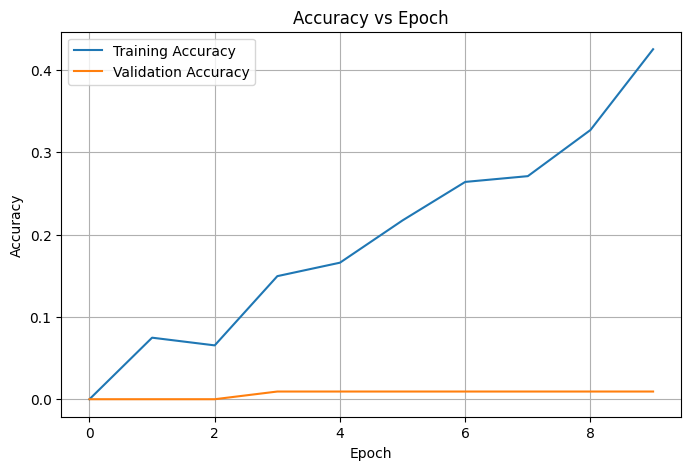

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

Loss vs Epoch

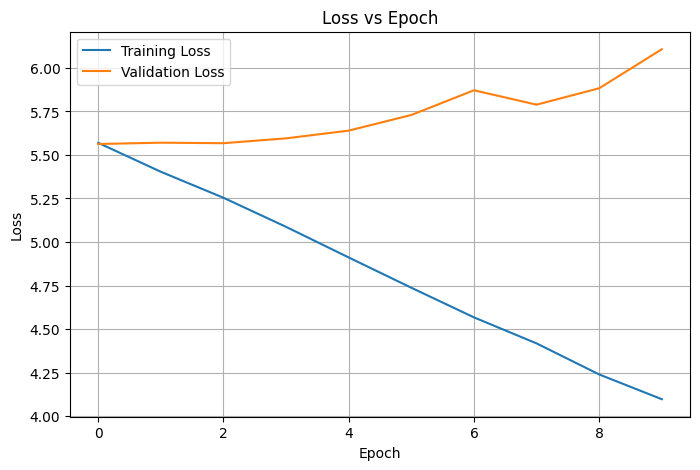

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

PART D — Text Generation

In [ ]:
def generate_text(seed_text, next_words=30):

    for _ in range(next_words):

        # Convert seed text into tokens
        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        # Keep only the last sequence_length words
        token_list = token_list[-sequence_length:]

        # Pad sequence
        token_list = pad_sequences(
            [token_list],
            maxlen=sequence_length,
            padding="pre"
        )

        # Predict next word
        predicted_probabilities = model.predict(
            token_list,
            verbose=0
        )

        predicted_id = np.argmax(predicted_probabilities, axis=-1)[0]

        # Convert predicted ID to word
        output_word = index_word.get(
            predicted_id,
            ""
        )

        # Add predicted word
        seed_text += " " + output_word

    return seed_text

Generate first text

In [ ]:
seed_text = "to be or not"

generated_text = generate_text(
    seed_text,
    next_words=30
)

print("Generated Text:\n")
print(generated_text)

Generated Text:

to be or not come come is lift relieve second that is here second the us agrippa citizen to to first citizen the the to to the us i he citizen the us say


Generate multiple samples

In [ ]:
seed_sentences = [
    "to be or not",
    "the king is",
    "love is",
    "my lord",
    "what is"
]

for seed in seed_sentences:

    print("=" * 70)
    print("Seed:", seed)

    generated = generate_text(
        seed,
        next_words=30
    )

    print("Generated:")
    print(generated)

Seed: to be or not
Generated:
to be or not come come is lift relieve second that is here second the us agrippa citizen to to first citizen the the to to the us i he citizen the us say
Seed: the king is
Generated:
the king is is is is is he is we we not not the us he he we we he second to to the citizen the us fortnight their impediment impediment impediment cracking
Seed: love is
Generated:
love is is is is is is relieve is we we not we the we he the he the he to to to to to citizen us but us rather rather rather
Seed: my lord
Generated:
my lord relieve is relieve is he is we we is second we us he what he to he you to the to the you the second the citizen the the citizen
Seed: what is
Generated:
what is is is is is we relieve is we we not second the we he not to the first citizen to to to citizen citizen us for us their report now


Better Text Generation Using Random Sampling

In [ ]:
def generate_text_sampling(seed_text, next_words=30, temperature=0.8):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = token_list[-sequence_length:]

        token_list = pad_sequences(
            [token_list],
            maxlen=sequence_length,
            padding="pre"
        )

        predictions = model.predict(
            token_list,
            verbose=0
        )[0]

        # Apply temperature
        predictions = np.asarray(predictions).astype("float64")
        predictions = np.log(predictions + 1e-8) / temperature
        exp_predictions = np.exp(predictions)
        predictions = exp_predictions / np.sum(exp_predictions)

        # Randomly select next word
        predicted_id = np.random.choice(
            len(predictions),
            p=predictions
        )

        output_word = index_word.get(
            predicted_id,
            ""
        )

        seed_text += " " + output_word

    return seed_text

In [ ]:
seed = "to be or not"

print(generate_text_sampling(
    seed,
    next_words=50,
    temperature=0.8
))

to be or not ten these knees caius any capitol make cannot would rather poor too virtue now famish resolved himself here which side chief he talking yield 'em shouts senate no be first be die famish us people and famish i chief we it our to first be i had that further link
